Implementation of 2D arrayed C++ program that runs the Game of Life generations in parallel on the GPU.

In [17]:
%%writefile game_of_life.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <ctime>
#include <fstream>
#include <sstream>
#include <iomanip>

const int WIDTH = 1024;
const int HEIGHT = 1024;
const int NUM_GENERATIONS = 100;

inline int idx(int x, int y) { return y * WIDTH + x; }

int countAliveNeighbors(const std::vector<int>& grid, int x, int y) {
    int alive = 0;
    for (int dy = -1; dy <= 1; ++dy) {
        for (int dx = -1; dx <= 1; ++dx) {
            if (dx == 0 && dy == 0) continue;
            int nx = x + dx, ny = y + dy;
            if (nx >= 0 && nx < WIDTH && ny >= 0 && ny < HEIGHT) {
                alive += grid[idx(nx, ny)];
            }
        }
    }
    return alive;
}

int nextState(int current, int aliveNeighbors) {
    if (current == 1 && aliveNeighbors < 2) return 0;
    if (current == 1 && (aliveNeighbors == 2 || aliveNeighbors == 3)) return 1;
    if (current == 1 && aliveNeighbors > 3) return 0;
    if (current == 0 && aliveNeighbors == 3) return 1;
    return current;
}

void savePGM(const std::vector<int>& grid, int generation) {
    std::ostringstream filename;
    filename << "frames/frame_" << std::setw(4) << std::setfill('0') << generation << ".pgm";
    std::ofstream file(filename.str(), std::ios::binary);
    file << "P5\n" << WIDTH << " " << HEIGHT << "\n255\n";
    for (int i = 0; i < WIDTH * HEIGHT; ++i) {
        unsigned char pixel = grid[i] ? 255 : 0;
        file.write(reinterpret_cast<char*>(&pixel), 1);
    }
}

int main() {
    std::srand(42); // fixed seed -> use the same seed in your CUDA version for a fair, identical-input comparison

    std::vector<int> current(WIDTH * HEIGHT);
    std::vector<int> next(WIDTH * HEIGHT);

    for (auto& cell : current) cell = (rand() % 10 == 0) ? 1 : 0;

    bool saveFrames = false;
    int saveEvery = 2;        // save every 2nd generation -> ~50 frames total

    if (saveFrames) system("mkdir -p frames");

    auto start = std::chrono::high_resolution_clock::now();

    for (int gen = 0; gen < NUM_GENERATIONS; ++gen) {
        for (int y = 0; y < HEIGHT; ++y) {
            for (int x = 0; x < WIDTH; ++x) {
                int alive = countAliveNeighbors(current, x, y);
                next[idx(x, y)] = nextState(current[idx(x, y)], alive);
            }
        }
        current.swap(next);

        if (saveFrames && gen % saveEvery == 0) savePGM(current, gen);
    }

    auto end = std::chrono::high_resolution_clock::now();
    double elapsed_ms = std::chrono::duration<double, std::milli>(end - start).count();

    std::cout << "Grid: " << WIDTH << "x" << HEIGHT << "\n";
    std::cout << "Generations: " << NUM_GENERATIONS << "\n";
    std::cout << "Total time: " << elapsed_ms << " ms\n";
    std::cout << "Avg time/generation: " << (elapsed_ms / NUM_GENERATIONS) << " ms\n";

    return 0;
}

Overwriting game_of_life.cpp


Compile the program and executes the Game of Life simulation.

In [18]:
!g++ -O2 -std=c++17 game_of_life.cpp -o game_of_life
!./game_of_life

game_of_life.cpp: In function ‘int main()’:
game_of_life.cpp:60:27: warning: ignoring return value of ‘int system(const char*)’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
   60 |     if (saveFrames) system("mkdir -p frames");
      |                     ~~~~~~^~~~~~~~~~~~~~~~~~~
Grid: 1024x1024
Generations: 100
Total time: 3610.63 ms
Avg time/generation: 36.1063 ms


Verify that the simulation successfully produced the expected number of saved image frames.

In [19]:
!ls frames/ | head
!ls frames/ | wc -l

frame_0000.pgm
frame_0002.pgm
frame_0004.pgm
frame_0006.pgm
frame_0008.pgm
frame_0010.pgm
frame_0012.pgm
frame_0014.pgm
frame_0016.pgm
frame_0018.pgm
50


Convert the saved simulation frames into an animated GIF so the evolution of the cellular grid can be visualized.

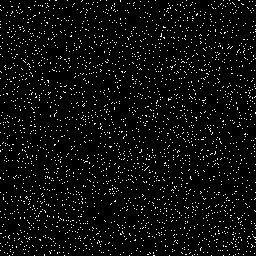

In [20]:
from PIL import Image
import glob
from IPython.display import Image as IPImage

frames = []
for filename in sorted(glob.glob("frames/frame_*.pgm")):
    img = Image.open(filename).resize((256, 256), Image.NEAREST)  # keep cells crisp, no blur
    frames.append(img)

frames[0].save("game_of_life.gif", save_all=True, append_images=frames[1:], duration=150, loop=0)
IPImage("game_of_life.gif")

Count the alive cells in each frame to help verify that the CPU implementation produces consistent results for comparison with the GPU version.

In [21]:
def count_alive(filename):
    with open(filename, 'rb') as f:
        f.readline(); w, h = map(int, f.readline().split()); f.readline()
        return sum(1 for b in f.read() if b == 255)

for fn in sorted(glob.glob("frames/frame_*.pgm")):
    print(fn, count_alive(fn))

frames/frame_0000.pgm 50835
frames/frame_0002.pgm 38004
frames/frame_0004.pgm 36469
frames/frame_0006.pgm 37375
frames/frame_0008.pgm 39633
frames/frame_0010.pgm 40698
frames/frame_0012.pgm 41819
frames/frame_0014.pgm 43415
frames/frame_0016.pgm 44031
frames/frame_0018.pgm 44637
frames/frame_0020.pgm 45092
frames/frame_0022.pgm 45318
frames/frame_0024.pgm 45684
frames/frame_0026.pgm 45906
frames/frame_0028.pgm 45666
frames/frame_0030.pgm 45731
frames/frame_0032.pgm 45849
frames/frame_0034.pgm 46136
frames/frame_0036.pgm 46486
frames/frame_0038.pgm 46382
frames/frame_0040.pgm 46602
frames/frame_0042.pgm 46882
frames/frame_0044.pgm 47108
frames/frame_0046.pgm 47320
frames/frame_0048.pgm 47252
frames/frame_0050.pgm 47257
frames/frame_0052.pgm 47063
frames/frame_0054.pgm 47282
frames/frame_0056.pgm 47313
frames/frame_0058.pgm 47088
frames/frame_0060.pgm 47114
frames/frame_0062.pgm 47588
frames/frame_0064.pgm 47669
frames/frame_0066.pgm 47988
frames/frame_0068.pgm 47734
frames/frame_0070.pg